# Day 1 - 세션 3 : "더 복잡한 모델을 쓰면 정말 나아질까?"

세션 2 마지막(STEP 9)에서 우리는 흥미로운 결과를 직접 확인했습니다.  
같은 1D-CNN 모델도 **학습 때 본 결함 크기**와 **평가 때 본 결함 크기**가 달라지자  
Accuracy가 **99% → 약 58%로 뚝 떨어졌습니다.**

이번 세션에서 던질 질문은 단 하나입니다.

> **"더 복잡한 모델(CNN-LSTM)을 쓰면 이 문제가 풀릴까?"**

직접 실험해보고 결과를 비교한 뒤, 아래 세 가지를 살펴봅니다.

- 복잡한 모델이 **항상 더 좋은 답은 아닐 수 있다**는 것
- 그렇다면 **LSTM이 진짜 힘을 발휘하는 상황**은 언제인지
- 그 개념을 우리 현장 설비에 어떻게 연결할 수 있는지 **시나리오 문서**로 정리

## 🎯 오늘의 목표
1. CNN-LSTM 구조를 이해하고 직접 학습시킨다
2. 1D-CNN과 CNN-LSTM 성능을 두 가지 조건에서 비교한다
   - (A) 동일 조건 split (세션 2 메인 파이프라인)
   - (B) 결함 크기 변화 split (세션 2 STEP 9, 약 58%였던 그 실험)
3. "복잡한 모델이 항상 정답은 아니다"를 데이터로 직접 확인한다
4. LSTM이 진짜 강점을 보이는 상황(여러 시점에 걸친 추세)을 이해한다
5. 우리 현장 설비(분쇄기·킬른·송풍기)에 적용하는 시나리오를 작성해본다


In [1]:
# 필요한 라이브러리 불러오기
import re
import platform

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

%matplotlib inline
# 그래프 한글 깨짐 방지 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위해 랜덤 시드 고정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 사용 가능한 GPU가 있으면 사용 (CUDA > MPS(Apple Silicon) > CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용할 디바이스: {device}")

사용할 디바이스: cpu


## STEP 1. 데이터 준비 - 세션 2의 leak-free 파이프라인 재사용

세션 1·2에서 만든 전처리 파이프라인을 그대로 재사용합니다.  
(시간순 80/20 분리 → 슬라이딩 윈도우 → FFT → 정규화, 자세한 설명은 세션 2 참고)

이번에는 **동일 조건 split** (세션 2 메인 결과, ~99%)을 기준선으로,
나중에 **결함 크기 변화 split** (세션 2 STEP 9, ~58%)도 함께 비교합니다.


In [2]:
def sliding_window(signal, window_size=2048, step=1024):
    """긴 신호를 (window_size) 크기의 여러 조각으로 잘라낸다."""
    segments = []
    for start in range(0, len(signal) - window_size, step):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


def compute_fft(segment, fs=48000):
    """시간 영역 윈도우를 주파수 영역(FFT)으로 변환한다."""
    n = len(segment)
    fft_vals = np.abs(np.fft.rfft(segment))[:n // 2]
    return fft_vals


def get_de_signal(filepath):
    """.mat 파일에서 DE(Drive End) 채널 신호를 정확한 키로 찾아서 반환한다."""
    m = loadmat(filepath)
    file_num = re.search(r'_(\d+)\.mat$', filepath).group(1)
    de_key = f'X{file_num}_DE_time'
    return m[de_key].squeeze()


def train_test_split(signal, train_size=0.8):
    """1차원 신호를 시간 순서대로 앞부분(train) / 뒷부분(test)으로 나눈다."""
    size = round(signal.shape[0] * train_size)
    return signal[:size], signal[size:]


# 파일 경로 → 클래스 레이블 매핑 (0: Normal, 1: Inner Race, 2: Outer Race, 3: Ball)
file_label_map = {
    'dataset/raw/Time_Normal_1_098.mat':  0,
    'dataset/raw/IR007_1_110.mat':        1,
    'dataset/raw/IR014_1_175.mat':        1,
    'dataset/raw/IR021_1_214.mat':        1,
    'dataset/raw/OR007_6_1_136.mat':      2,
    'dataset/raw/OR014_6_1_202.mat':      2,
    'dataset/raw/OR021_6_1_239.mat':      2,
    'dataset/raw/B007_1_123.mat':         3,
    'dataset/raw/B014_1_190.mat':         3,
    'dataset/raw/B021_1_227.mat':         3,
}
class_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball']


def load_and_preprocess_cwru_dataset(
    file_label_map, window_size=2048, step=1024, fs=48000, train_size=0.8,
):
    """CWRU Bearing 데이터셋 전처리 파이프라인 전체 (세션 1·2 STEP 7과 동일한 순서).

    Data Leakage 방지: 파일별 원본 신호를 시간 순서대로 train/test로 나눈 뒤
    윈도우 슬라이싱 + FFT를 적용한다.
    """
    X_train_list, y_train_list = [], []
    X_test_list,  y_test_list  = [], []

    for filepath, label in file_label_map.items():
        signal = get_de_signal(filepath)
        train_signal, test_signal = train_test_split(signal, train_size=train_size)

        for seg in sliding_window(train_signal, window_size=window_size, step=step):
            X_train_list.append(compute_fft(seg, fs=fs))
            y_train_list.append(label)

        for seg in sliding_window(test_signal, window_size=window_size, step=step):
            X_test_list.append(compute_fft(seg, fs=fs))
            y_test_list.append(label)

    X_train = np.array(X_train_list)
    X_test  = np.array(X_test_list)
    y_train = np.array(y_train_list)
    y_test  = np.array(y_test_list)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


In [3]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = load_and_preprocess_cwru_dataset(file_label_map)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"클래스 종류: {class_names}")

X_train_scaled: (3702, 1024)
X_test_scaled : (914, 1024)
클래스 종류: ['Normal', 'Inner Race', 'Outer Race', 'Ball']


## STEP 2. PyTorch 입력 형태로 변환하기

세션 2와 동일하게, `(배치, 채널, 길이)` 형태의 텐서로 변환하고 DataLoader를 만듭니다.

In [4]:
# numpy 배열 → PyTorch tensor 변환
# unsqueeze(1): (N, 1024) → (N, 1, 1024)  (채널 차원 추가)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"X_train_tensor shape: {X_train_tensor.shape}  (배치, 채널, 길이)")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

# Dataset + DataLoader 구성 (배치 크기 32)
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 첫 번째 배치 확인
xb, yb = next(iter(train_loader))
print(f"\n배치 1개 shape: x={xb.shape}, y={yb.shape}")

X_train_tensor shape: torch.Size([3702, 1, 1024])  (배치, 채널, 길이)
y_train_tensor shape: torch.Size([3702])

배치 1개 shape: x=torch.Size([32, 1, 1024]), y=torch.Size([32])


## STEP 3. 공통 학습 함수 준비

세션 2 마지막에 만들었던 `train_and_evaluate()` 함수를 다시 사용합니다.
이 함수에 **1D-CNN**과 **CNN-LSTM** 모델을 각각 넣어서 학습시키면,
"모델 구조만 다르고 나머지 학습 과정은 동일한" 상태에서 두 모델을 공정하게 비교할 수 있습니다.

In [5]:
def train_and_evaluate(model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3):
    """
    주어진 모델을 학습시키고, 테스트 데이터로 평가한다.

    Parameters
    ----------
    model : 학습할 PyTorch 모델 (nn.Module)
    train_loader : 학습 데이터 DataLoader
    X_test_tensor, y_test : 테스트 입력(tensor)과 정답 레이블(numpy)
    num_epochs : 학습 에폭 수
    lr : learning rate

    Returns
    -------
    model        : 학습이 끝난 모델
    loss_history : 에폭별 평균 loss 리스트
    accuracy     : 테스트 Accuracy
    y_pred       : 테스트 데이터에 대한 예측 클래스
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor.to(device)).argmax(dim=1).cpu().numpy()
    accuracy = accuracy_score(y_test, y_pred)

    return model, loss_history, accuracy, y_pred

## STEP 4. 베이스라인 : 1D-CNN 다시 학습하기

비교의 기준(베이스라인)이 될 1D-CNN 모델을 세션 2와 동일한 구조로 다시 학습시킵니다.

In [6]:
class CNN1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        # Conv+Pool을 두 번 거치면 길이: 1024 → 512 → 256
        self.fc1 = nn.Linear(32 * 256, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # → (배치, 16, 512)
        x = self.pool(self.relu(self.conv2(x)))   # → (배치, 32, 256)
        x = x.flatten(start_dim=1)                # → (배치, 32*256)
        x = self.relu(self.fc1(x))                # → (배치, 64)
        return self.fc2(x)                        # → (배치, 4)


torch.manual_seed(SEED)
cnn_model = CNN1D(num_classes=4)
cnn_model, cnn_history, cnn_acc, cnn_pred = train_and_evaluate(
    cnn_model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3
)
print(f"[1D-CNN] 테스트 Accuracy: {cnn_acc * 100:.2f}%")
print(f"[1D-CNN] 최종 Loss: {cnn_history[-1]:.4f}")

[1D-CNN] 테스트 Accuracy: 99.67%
[1D-CNN] 최종 Loss: 0.0001


## STEP 4 결과 : 1D-CNN Confusion Matrix

베이스라인 모델의 Confusion Matrix를 확인합니다. 이 결과가 CNN-LSTM과 비교할 "기준선"이 됩니다.

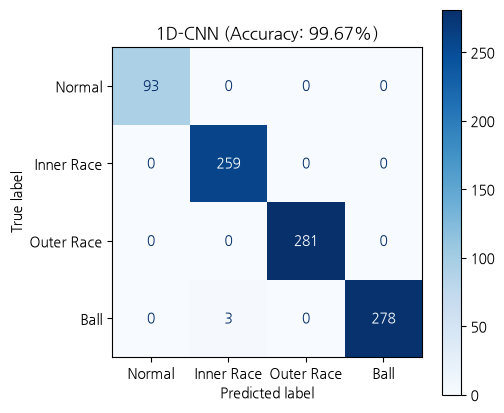

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, cnn_pred, display_labels=class_names, cmap='Blues', ax=ax)
ax.set_title(f"1D-CNN (Accuracy: {cnn_acc*100:.2f}%)")
plt.show()

## STEP 5. CNN-LSTM 구조 이해하기

### 1D-CNN이 하지 못하는 것
1D-CNN은 **한 윈도우(2048 포인트) 안**에서 주파수 패턴을 찾아냅니다.  
"이 패턴들이 **시간 순서상 어떻게 이어지는가**"는 직접 모델링하지 않습니다.

### LSTM 핵심 직관
> **"중요한 것은 오래 기억하고, 불필요한 것은 잊는다"**  
> CNN이 "지금 이 순간의 패턴"을 본다면, LSTM은 "그 패턴들의 시간적 흐름"을 봅니다.

### CNN-LSTM 연결 구조
```
FFT 입력 (길이 1024)
        ↓
  [1D-CNN 블록]   → 로컬 주파수 패턴 추출 (1024 → 256 → 64 길이로 압축)
        ↓
  [LSTM 블록]     → 64개 특징의 '순서·흐름' 학습
        ↓
  [Fully Connected] → 4클래스 분류
```

> ⚠️ 이번 실습에서 LSTM이 보는 '시퀀스'는 **여러 날에 걸친 측정값이 아니라**,  
> CNN이 FFT 특징을 추출한 뒤 남은 64개 위치의 순서입니다.  
> 진짜 시간 흐름 데이터가 아니기 때문에 결과가 예상과 다를 수 있습니다 — 직접 확인해봅시다.


In [8]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4, hidden_size=64):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(kernel_size=2)
        # 추가 pooling: LSTM에 넣기 좋은 시퀀스 길이(64)로 한 번 더 줄인다 (256 → 64)
        self.pool_seq = nn.MaxPool1d(kernel_size=4)
        self.relu = nn.ReLU()

        # LSTM 입력: (배치, 시퀀스 길이=64, 특징 수=32)
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (배치, 1, 1024)
        x = self.pool(self.relu(self.conv1(x)))   # → (배치, 16, 512)
        x = self.pool(self.relu(self.conv2(x)))   # → (배치, 32, 256)
        x = self.pool_seq(x)                      # → (배치, 32, 64)

        x = x.permute(0, 2, 1)                    # → (배치, 64, 32)  (LSTM 입력 형태)

        _, (h_n, _) = self.lstm(x)                # h_n: (1, 배치, hidden_size)
        x = h_n[-1]                                # → (배치, hidden_size)  : 시퀀스를 끝까지 읽은 후의 최종 상태

        return self.fc(x)                          # → (배치, 4)


cnn_lstm_model = CNNLSTM(num_classes=4)
print(cnn_lstm_model)

dummy_input = torch.randn(4, 1, 1024)
dummy_output = cnn_lstm_model(dummy_input)
print(f"\n더미 입력 shape : {dummy_input.shape}")
print(f"더미 출력 shape : {dummy_output.shape}  (배치 4개 × 클래스 4개 점수)")

CNNLSTM(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool_seq): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

더미 입력 shape : torch.Size([4, 1, 1024])
더미 출력 shape : torch.Size([4, 4])  (배치 4개 × 클래스 4개 점수)


## STEP 6. CNN-LSTM 학습하기

같은 `train_and_evaluate()` 함수를 사용합니다.  
LSTM은 수렴이 느린 경향이 있어 에폭 수와 learning rate를 조금 다르게 줍니다 (30 에폭, lr=0.002).  

학습 전에 예상해보세요 — 1D-CNN(STEP 4)보다 정확도가 올라갈까요, 비슷할까요?


In [9]:
torch.manual_seed(SEED)
cnn_lstm_model = CNNLSTM(num_classes=4)
cnn_lstm_model, lstm_history, lstm_acc, lstm_pred = train_and_evaluate(
    cnn_lstm_model, train_loader, X_test_tensor, y_test, num_epochs=30, lr=2e-3
)
print(f"[CNN-LSTM] 테스트 Accuracy: {lstm_acc * 100:.2f}%")
print(f"[CNN-LSTM] 최종 Loss: {lstm_history[-1]:.4f}")

[CNN-LSTM] 테스트 Accuracy: 97.37%
[CNN-LSTM] 최종 Loss: 0.0511


## STEP 7. 1D-CNN vs CNN-LSTM 비교 - 동일 조건에서

같은 데이터, 같은 조건(동일 결함 크기 안에서 시간순 80/20 분리)에서 두 모델을 비교합니다.  
결과가 예상과 다르다면, 그 이유를 같이 생각해봅시다.


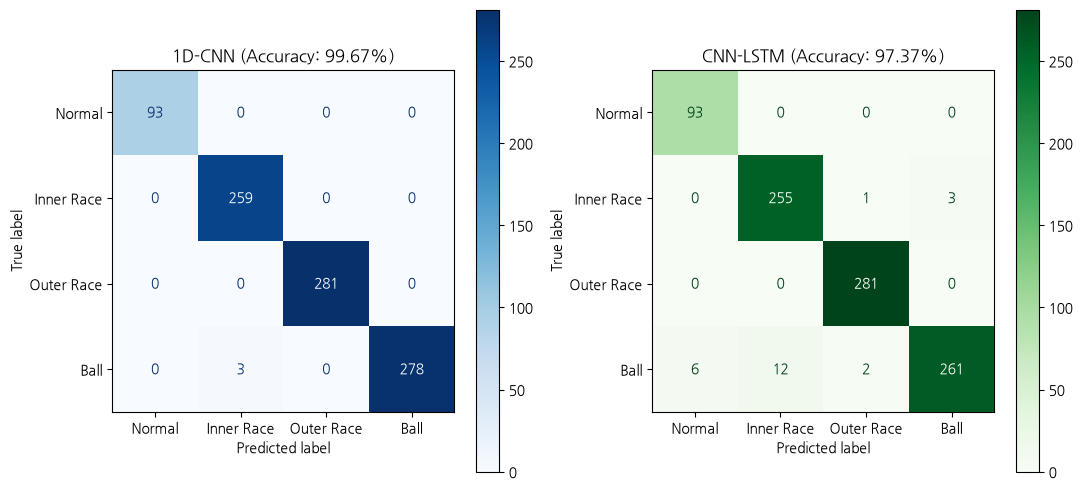

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(y_test, cnn_pred, display_labels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title(f"1D-CNN (Accuracy: {cnn_acc*100:.2f}%)")

ConfusionMatrixDisplay.from_predictions(y_test, lstm_pred, display_labels=class_names, cmap='Greens', ax=axes[1])
axes[1].set_title(f"CNN-LSTM (Accuracy: {lstm_acc*100:.2f}%)")

plt.tight_layout()
plt.show()

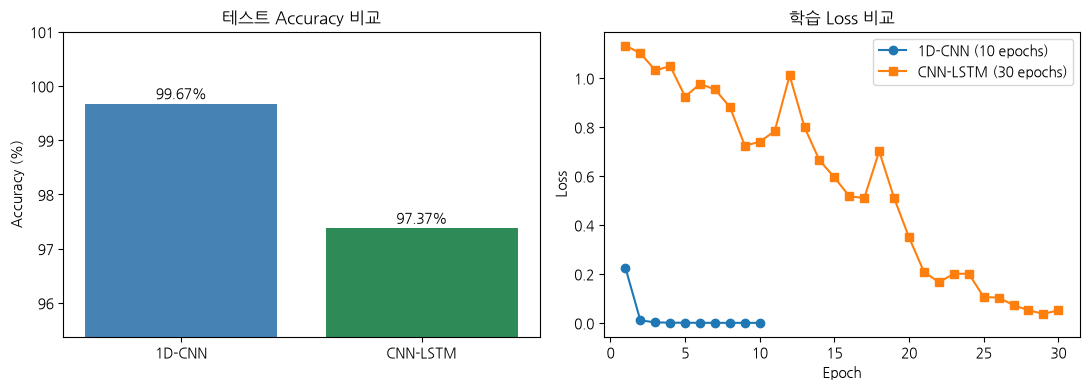

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

accs = [cnn_acc * 100, lstm_acc * 100]
axes[0].bar(['1D-CNN', 'CNN-LSTM'], accs, color=['steelblue', 'seagreen'])
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(min(accs) - 2, 101)
axes[0].set_title('테스트 Accuracy 비교')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha='center')

axes[1].plot(range(1, len(cnn_history) + 1), cnn_history, marker='o', label='1D-CNN (10 epochs)')
axes[1].plot(range(1, len(lstm_history) + 1), lstm_history, marker='s', label='CNN-LSTM (30 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('학습 Loss 비교')
axes[1].legend()

plt.tight_layout()
plt.show()

## STEP 8. 세션 2의 질문으로 돌아가기 - 결함 크기가 달라지면?

동일 조건에서는 1D-CNN과 CNN-LSTM이 비슷한 결과를 보였습니다.  
그렇다면 세션 2 STEP 9에서 확인한 **"결함 크기 변화(Domain Shift)"** 문제는 CNN-LSTM으로 풀릴까요?

아래 셀에서 두 모델을 동일한 조건(007mil + 014mil → 학습, 021mil → 평가)으로 비교합니다.  
실행 전에 먼저 예상해보세요.


학습: 007mil + 014mil (3114개)  /  평가: 021mil (1515개)
1D-CNN   → Test Accuracy: 58.02%
CNN-LSTM → Test Accuracy: 61.25%


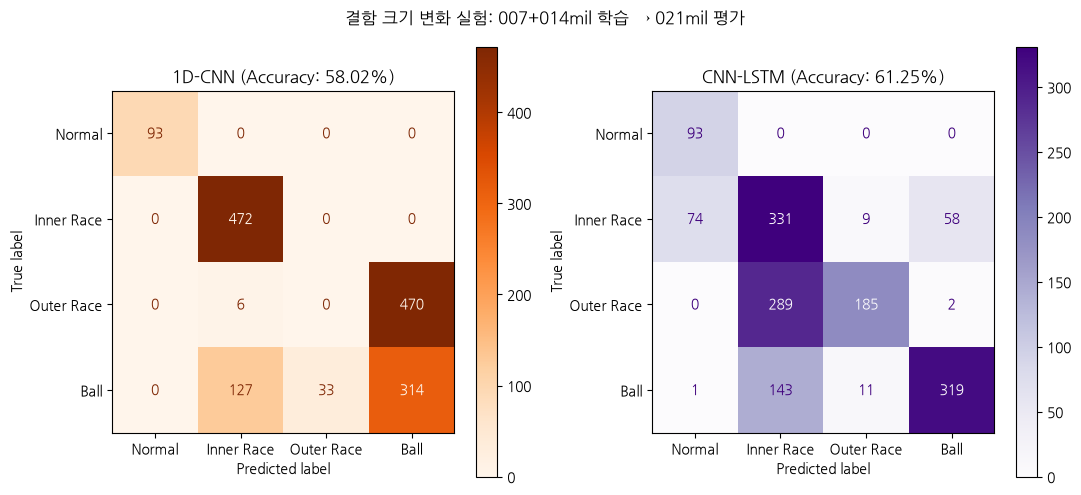

In [12]:
# 결함 크기 기준 split: 007mil + 014mil로 학습, 021mil(처음 보는 크기)로 평가
# 1D-CNN과 CNN-LSTM을 동일한 조건에서 비교

fault_size_groups = {
    1: (['IR007_1_110.mat', 'IR014_1_175.mat'], 'IR021_1_214.mat'),
    2: (['OR007_6_1_136.mat', 'OR014_6_1_202.mat'], 'OR021_6_1_239.mat'),
    3: (['B007_1_123.mat', 'B014_1_190.mat'], 'B021_1_227.mat'),
}
normal_file = 'Time_Normal_1_098.mat'

X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

# Normal: 파일 1개이므로 시간순 80/20 분리
normal_signal = get_de_signal(f'dataset/raw/{normal_file}')
normal_train, normal_test = train_test_split(normal_signal, train_size=0.8)
for seg in sliding_window(normal_train):
    X_train_list.append(compute_fft(seg)); y_train_list.append(0)
for seg in sliding_window(normal_test):
    X_test_list.append(compute_fft(seg));  y_test_list.append(0)

# 결함 클래스: 007mil + 014mil → 학습 / 021mil(처음 보는 결함 크기) → 평가
for label, (train_files, test_file) in fault_size_groups.items():
    for f in train_files:
        sig = get_de_signal(f'dataset/raw/{f}')
        for seg in sliding_window(sig):
            X_train_list.append(compute_fft(seg)); y_train_list.append(label)
    sig = get_de_signal(f'dataset/raw/{test_file}')
    for seg in sliding_window(sig):
        X_test_list.append(compute_fft(seg)); y_test_list.append(label)

X_train_sev = np.array(X_train_list);  X_test_sev = np.array(X_test_list)
y_train_sev = np.array(y_train_list);  y_test_sev = np.array(y_test_list)

scaler_sev = StandardScaler()
X_train_sev_scaled = scaler_sev.fit_transform(X_train_sev)
X_test_sev_scaled  = scaler_sev.transform(X_test_sev)

X_train_sev_t = torch.tensor(X_train_sev_scaled, dtype=torch.float32).unsqueeze(1)
X_test_sev_t  = torch.tensor(X_test_sev_scaled,  dtype=torch.float32).unsqueeze(1)
y_train_sev_t = torch.tensor(y_train_sev, dtype=torch.long)
train_loader_sev = DataLoader(TensorDataset(X_train_sev_t, y_train_sev_t),
                              batch_size=BATCH_SIZE, shuffle=True)

# 1D-CNN
torch.manual_seed(SEED)
sev_cnn = CNN1D(num_classes=4)
sev_cnn, _, sev_cnn_acc, sev_cnn_pred = train_and_evaluate(
    sev_cnn, train_loader_sev, X_test_sev_t, y_test_sev, num_epochs=10, lr=1e-3
)

# CNN-LSTM
torch.manual_seed(SEED)
sev_lstm = CNNLSTM(num_classes=4)
sev_lstm, _, sev_lstm_acc, sev_lstm_pred = train_and_evaluate(
    sev_lstm, train_loader_sev, X_test_sev_t, y_test_sev, num_epochs=30, lr=2e-3
)

print(f"학습: 007mil + 014mil ({len(y_train_sev)}개)  /  평가: 021mil ({len(y_test_sev)}개)")
print(f"1D-CNN   → Test Accuracy: {sev_cnn_acc  * 100:.2f}%")
print(f"CNN-LSTM → Test Accuracy: {sev_lstm_acc * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_sev, sev_cnn_pred, display_labels=class_names, cmap="Oranges", ax=axes[0])
axes[0].set_title(f"1D-CNN (Accuracy: {sev_cnn_acc*100:.2f}%)")
ConfusionMatrixDisplay.from_predictions(
    y_test_sev, sev_lstm_pred, display_labels=class_names, cmap="Purples", ax=axes[1])
axes[1].set_title(f"CNN-LSTM (Accuracy: {sev_lstm_acc*100:.2f}%)")
plt.suptitle("결함 크기 변화 실험: 007+014mil 학습 → 021mil 평가", fontsize=12)
plt.tight_layout()
plt.show()


## STEP 9. 결과 해석 - 무엇을 배웠나?

### 실험 결과 정리

| 조건 | 1D-CNN | CNN-LSTM |
|---|---|---|
| 동일 조건 (같은 결함 크기 안에서 시간순 분리) | ~99% | ~97% |
| 결함 크기 변화 (007+014mil 학습 → 021mil 평가) | ~58% | ~61% |

두 가지 교훈이 있습니다.

**① 복잡한 모델이 항상 더 좋은 답은 아니다**

동일 조건에서는 CNN-LSTM이 1D-CNN보다 오히려 낮게 나오기도 했습니다.  
더 많은 파라미터와 더 긴 학습 시간을 투입했는데 결과가 더 나빠질 수 있습니다.  
→ AI 모델 선택의 기준은 "더 복잡한가"가 아니라 **"이 문제에 맞는 구조인가"**입니다.

**② 모델 구조를 바꾸는 것만으로는 Domain Shift를 해결할 수 없다**

CNN-LSTM으로 바꿔도 결함 크기 변화 문제(~58%→~61%)는 거의 개선되지 않았습니다.  
이것은 구조의 문제가 아니라 **"모델이 학습 때 본 적 없는 조건"** 의 문제이기 때문입니다.  
→ 해결의 핵심은 더 좋은 모델이 아니라, **더 다양한 조건의 데이터를 학습에 포함**시키는 것입니다.

### 그렇다면 LSTM은 언제 진짜 힘을 발휘할까?

LSTM의 진짜 강점은 **"여러 시점에 걸친 변화 추세"** 를 학습하는 데 있습니다.  
이번 실습에서는 한 윈도우의 FFT를 LSTM에 넣었기 때문에, 진짜 시간 흐름을 보지 못했습니다.  
만약 아래와 같은 데이터가 있다면 LSTM(또는 CNN-LSTM)이 분명한 이점을 가집니다:

- 베어링이 "정상 → 미세 이상 → 심각 이상 → 고장"으로 진행되는 **장기 추세 데이터**
- 진동뿐 아니라 온도·전류 등 **여러 센서값의 시간 추세**를 함께 학습하는 경우

### 🏭 시멘트 공장 실설비 적용 사례 (Nature, 2025)

실제 시멘트 공장 설비에서 CNN 계열 모델의 결함 진단 정확도:

| 설비 | 결함 유형 | 진단 정확도 |
|---|---|---|
| 롤러 프레스 | 내륜(Inner Race) 결함 | 94.64% |
| 원심팬 | 불균형 결함 | 97.62% |
| 메인 배기팬 | 외륜(Outer Race) 결함 | 95.43% |

CWRU보다 노이즈가 많은 실제 현장 데이터에서는 94~98% 수준입니다.  
여기에 장기 추세 데이터가 추가된다면 CNN-LSTM 구조가 추가 개선을 줄 가능성이 높아집니다.

### 🔄 한 가지 더 - "정상"의 기준은 고정돼 있지 않다

오늘 만든 모델은 특정 운전 조건에서의 "정상/고장 패턴"을 학습했습니다.  
실제 설비는 부하·속도·투입 원료 등 조건이 바뀌면 "정상" 진동 자체가 달라질 수 있습니다.  

→ 따라서 실무에서는 **주기적으로 최신 데이터로 모델을 재학습**하거나,  
운전 조건별로 모델/기준을 나누는 접근이 함께 고려되어야 합니다.  

"이 모델의 Accuracy는 99%입니다"라는 숫자 하나로는 부족합니다.  
**"어떤 조건에서 테스트한 99%인가요?"** 라고 되묻는 것이 현장 담당자의 중요한 역할입니다.


## STEP 10. 실습 - 우리 현장에 적용한다면?

지금까지 배운 내용을 우리 회사 설비에 연결해봅니다.  
아래 빈칸을 채워보세요. (정답은 없습니다 — 현장 경험에서 나오는 판단이 중요합니다.)

---

### 📋 설비 진단 AI 적용 시나리오

**1. 우리 설비 선택**

> 분석하고 싶은 설비와 고장 유형을 적어보세요.
> - 설비 이름: `(예: 분쇄기, 킬른 구동 감속기, 배기팬, 기타)`
> - 주요 고장 유형: `(예: 베어링 내륜 마모, 불균형, 축 정렬 불량)`

**2. 데이터 수집 계획**

> - 어떤 센서를 쓸 건가요? `(예: 진동 가속도계, 온도, 전류)`
> - 어디에 부착할 건가요? `(예: 베어링 하우징 수평 방향)`
> - 얼마나 자주 측정할 건가요? `(예: 1분마다 5초간 샘플링)`

**3. 학습 데이터 구성**

> - 정상 데이터는 언제/어떤 조건에서 수집할 건가요?
>   `(예: 정기 점검 직후 이상 없음 확인된 상태에서 1주일간)`
> - 고장 데이터는 어떻게 확보할 건가요?
>   `(예: 과거 고장 이력 + 현장 모사 테스트 + CWRU 공개 데이터 전이학습)`

**4. 운전 조건 변화 고려**

> STEP 8에서 봤듯이, 조건이 달라지면 모델 성능이 떨어질 수 있습니다.
> - 우리 설비에서 운전 조건이 자주 바뀌나요? `(예: 계절별 부하 변동, 원료 배합 변경)`
> - 그렇다면 모델을 얼마나 자주 재학습해야 할까요? `(예: 분기 1회, 반기 1회)`

**5. 현장 적용 시 판단 기준**

> 이 AI가 "고장 예측"을 하면, 실제로 어떤 행동을 취할 건가요?
> - 즉각 설비 정지? 정밀 점검 의뢰? 모니터링 강화?
> - "오경보(정상인데 고장으로 예측)"와 "미탐지(고장인데 정상으로 예측)" 중
>   우리 현장에서 더 위험한 것은 어느 쪽인가요?

---

> 💡 **이 워크시트가 실제 AI 도입 기획서의 출발점이 됩니다.**  
> 모델의 정확도(99%)보다 위의 다섯 가지 질문에 답할 수 있는 것이 현장 담당자에게 더 중요합니다.


## STEP 11. 모델 저장

학습된 CNN-LSTM 모델을 파일로 저장합니다.


In [13]:
import os

os.makedirs('models', exist_ok=True)
torch.save(cnn_lstm_model.state_dict(), 'models/cnn_lstm.pt')
print("저장 완료: models/cnn_lstm.pt")

저장 완료: models/cnn_lstm.pt


## STEP 12. 실습 - 하이퍼파라미터를 바꿔서 실험해보기

`train_and_evaluate()` 함수를 그대로 활용해서, CNN-LSTM의 `hidden_size`를 바꿔보고  
Accuracy/Loss가 어떻게 달라지는지 직접 확인해보세요.


In [14]:
# 🎯 실습: hidden_size를 128로 늘려서 CNN-LSTM을 다시 학습해보고,
# 기존 (hidden_size=64) 결과와 Accuracy를 비교해보세요.

torch.manual_seed(SEED)
cnn_lstm_128 = CNNLSTM(num_classes=4, hidden_size=128)
cnn_lstm_128, history_128, acc_128, pred_128 = train_and_evaluate(
    cnn_lstm_128, train_loader, X_test_tensor, y_test, num_epochs=30, lr=2e-3
)

print(f"CNN-LSTM (hidden_size=64)  → Accuracy: {lstm_acc * 100:.2f}%")
print(f"CNN-LSTM (hidden_size=128) → Accuracy: {acc_128 * 100:.2f}%")

CNN-LSTM (hidden_size=64)  → Accuracy: 97.37%
CNN-LSTM (hidden_size=128) → Accuracy: 99.67%
